# 📊 Customer Retention & Churn Dashboard

This interactive dashboard provides insights into customer churn behavior in a telecom company.

## The dashboard helps analyze:
- Customer churn rate
- Contract-based churn
- Payment method impact
- Internet service distribution
- Customer tenure patterns
- Monthly charge trends

---

## 💡 Key Insights

- Month-to-month contract customers show the highest churn.
- Customers with higher monthly charges are more likely to churn.
- Electronic check payment users have higher churn rates.
- Fiber optic users contribute significantly to churn.
- Long tenure customers are more loyal and stable.

---

## 🚀 Recommendations

- Introduce discounts for long-term contracts.
- Improve retention campaigns for high-risk customers.
- Optimize pricing for customers with high monthly charges.
- Improve service quality for fiber optic users.
- Encourage automatic payment methods for better retention.

---

## Conclusion

Key findings from the analysis:

- Month-to-month contract customers have higher churn.
- Customers with high monthly charges are more likely to churn.
- Long-term customers show better retention.
- Fiber optic internet users have relatively higher churn.

The analysis can help businesses improve customer retention strategies.

## Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

In [37]:
!pip install kaleido


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load the Dataset

In [38]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Data Cleaning

In [39]:
# Convert TotalCharges to numeric

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)


In [40]:
# Fill missing values

df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

C:\Users\Purvi jain\AppData\Local\Temp\ipykernel_31828\1560694977.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [41]:
# Convert SeniorCitizen

df['SeniorCitizen'] = df['SeniorCitizen'].replace({
    0:'No',
    1:'Yes'
})

## KPI Values

In [42]:
total_customers = len(df)
total_churn = df[df['Churn']=='Yes'].shape[0]

In [43]:
churn_rate = round(
    (total_churn / total_customers) * 100,
    2
)

avg_monthly_charges = round(
    df['MonthlyCharges'].mean(),
    2
)

avg_tenure = round(
    df['tenure'].mean(),
    2
)

## Colors

In [44]:
bg_color = '#0F172A'
card_color = '#1E293B'
blue = '#3B82F6'
green = '#10B981'
red = '#EF4444'
purple = '#8B5CF6'
orange = '#F59E0B'
white = 'white'

## Dashboard

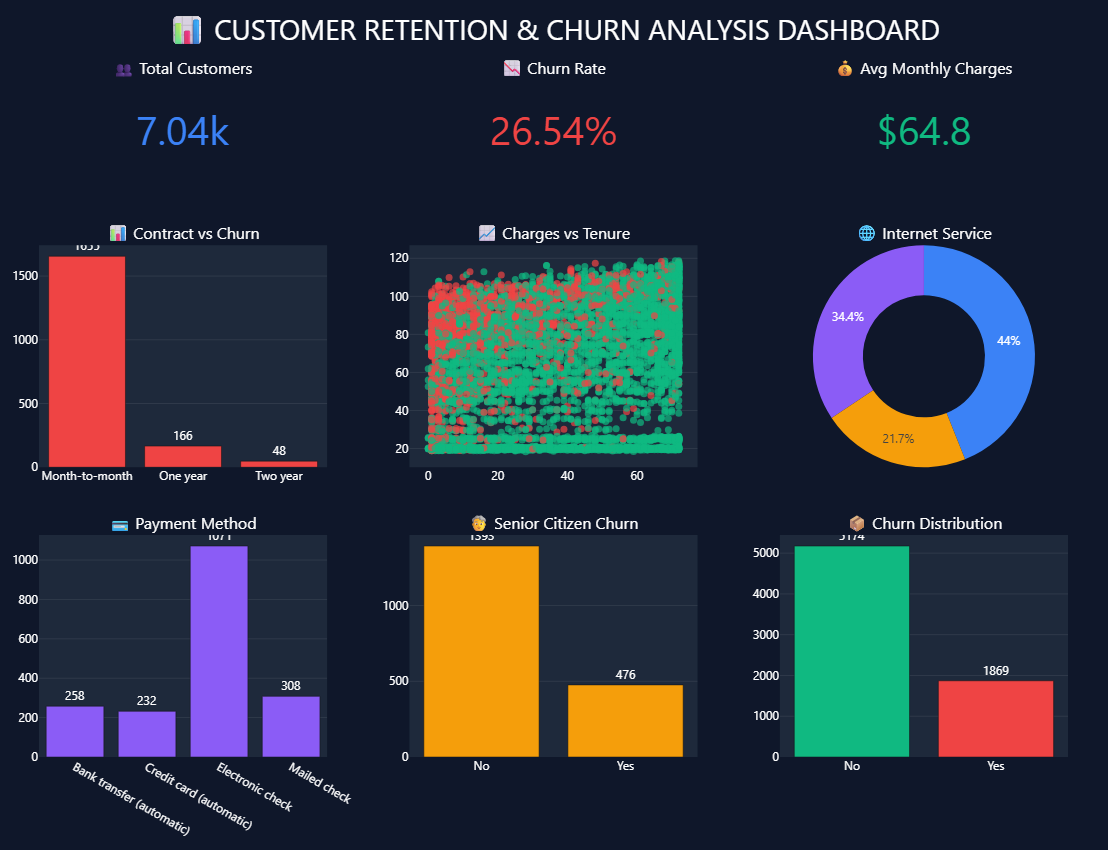

In [50]:
fig = make_subplots(

    rows=3,
    cols=3,

    row_heights=[0.18, 0.41, 0.41],

    specs=[

        [{"type":"indicator"},
         {"type":"indicator"},
         {"type":"indicator"}],

        [{"type":"xy"},
         {"type":"xy"},
         {"type":"domain"}],

        [{"type":"xy"},
         {"type":"xy"},
         {"type":"xy"}]
    ],

    subplot_titles=(

        "👥 Total Customers",
        "📉 Churn Rate",
        "💰 Avg Monthly Charges",

        "📊 Contract vs Churn",
        "📈 Charges vs Tenure",
        "🌐 Internet Service",

        "💳 Payment Method",
        "🧓 Senior Citizen Churn",
        "📦 Churn Distribution"
    ),

    vertical_spacing=0.10,
    horizontal_spacing=0.08
)

# KPI 1

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_customers,
        number={
            'font':{
                'size':40,
                'color':blue
            }
        }
    ),
    row=1,
    col=1
)


# KPI 2
fig.add_trace(
    go.Indicator(
        mode="number",
        value=churn_rate,
        number={
            'suffix':'%',
            'font':{
                'size':40,
                'color':red
            }
        }
    ),
    row=1,
    col=2
)

# KPI 3
fig.add_trace(
    go.Indicator(
        mode="number",
        value=avg_monthly,
        number={
            'prefix':'$',
            'font':{
                'size':40,
                'color':green
            }
        }
    ),
    row=1,
    col=3
)

# CONTRACT VS CHURN
contract = pd.crosstab(
    df['Contract'],
    df['Churn']
)

fig.add_trace(
    go.Bar(
        x=contract.index,
        y=contract['Yes'],
        marker_color=red,
        text=contract['Yes'],
        textposition='outside'
    ),
    row=2,
    col=1
)

# MONTHLY CHARGES VS TENURE
fig.add_trace(
    go.Scatter(
        x=df['tenure'],
        y=df['MonthlyCharges'],
        mode='markers',
        marker=dict(
            size=7,
            color=df['Churn'].map({
                'Yes':red,
                'No':green
            }),
            opacity=0.7
        )
    ),
    row=2,
    col=2
)

# INTERNET SERVICE
internet = df['InternetService'].value_counts()
fig.add_trace(
    go.Pie(
        labels=internet.index,
        values=internet.values,
        hole=0.55,
        marker=dict(
            colors=[blue, purple, orange]
        )
    ),
    row=2,
    col=3
)

# PAYMENT METHOD
payment = pd.crosstab(
    df['PaymentMethod'],
    df['Churn']
)
fig.add_trace(
    go.Bar(
        x=payment.index,
        y=payment['Yes'],
        marker_color=purple,
        text=payment['Yes'],
        textposition='outside'
    ),
    row=3,
    col=1
)

# SENIOR CITIZEN CHURN
senior = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn']
)
fig.add_trace(
    go.Bar(
        x=senior.index,
        y=senior['Yes'],
        marker_color=orange,
        text=senior['Yes'],
        textposition='outside'
    ),
    row=3,
    col=2
)

# CHURN DISTRIBUTION
churn = df['Churn'].value_counts()
fig.add_trace(
    go.Bar(
        x=churn.index,
        y=churn.values,
        marker_color=[green, red],
        text=churn.values,
        textposition='outside'
    ),
    row=3,
    col=3
)

# UPDATE LAYOUT
fig.update_layout(
    title={
        'text':
        '📊 CUSTOMER RETENTION & CHURN ANALYSIS DASHBOARD',
        'x':0.5,
        'font':{
            'size':28,
            'color':white
        }
    },
    template='plotly_dark',
    
    height=850,
    width=1050,

    paper_bgcolor=bg_color,
    plot_bgcolor=card_color,

    font=dict(
        family='Segoe UI',
        size=12,
        color=white
    ),

    margin=dict(
        l=30,
        r=30,
        t=80,
        b=30
    ),

    showlegend=False
)

# AXES STYLE
fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    color='white'
)
fig.update_yaxes(
    showgrid=True,
    gridcolor='rgba(255,255,255,0.08)',
    zeroline=False,
    color='white'
)

# SHOW DASHBOARD
fig.show()
